# ARTI-308: Lab 3 – EDA

This notebook covers **Exploratory Data Analysis (EDA)** as part of **Lab 3** for the  
**ARTI-308 Machine Learning** course.

The goal of this lab is to explore and understand the dataset before applying any
machine learning models.

The target variable in this dataset is **Status** (Alive or Dead), making this a
**binary classification problem**.

![Breast Cancer](Breast_Cancer_img.png)

## 1. Import Required Libraries

In [105]:
# Import required libraries for EDA and visualization
import pandas as pd # pandas is used for data loading and analysis
import matplotlib.pyplot as plt # matplotlib is used for plotting graphs
import seaborn as sns # seaborn provides more stylish and beautiful color palettes

## 2. Load the Dataset

In [106]:
# Load the dataset into a pandas DataFrame
C_df = pd.read_csv("Breast_Cancer.csv")

C_df.head() # display first 5 rows

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


## 3. Dataset Overview and Understanding
In this section, we examine the structure of the dataset.
Including column names, data types, and basic statistical information.

In [107]:
# Display the shape --> (rows, columns)
print("Dataset Shape:", C_df.shape) 

Dataset Shape: (4024, 16)


In [108]:
# Display all column names
C_df.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='object')

In [109]:
# Check column names, data types, and missing values
C_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [110]:
# Statistical summary for numerical columns
C_df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [111]:
# Count values of the target variable
C_df["Status"].value_counts()

Status
Alive    3408
Dead      616
Name: count, dtype: int64

## 4. Data Visualization

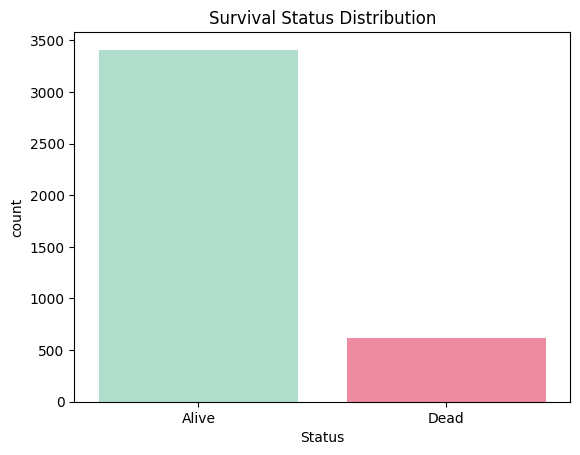

In [ ]:
# Visualize status distribution
sns.countplot(x="Status", hue="Status", data=C_df, palette=["#A7E7CD", "#FD7C96"], legend=False)
plt.title("Survival Status Distribution")
plt.show()

This plot shows that the target variable is **imbalanced**: most patients are Alive and fewer are Dead, so we should be careful with evaluation metrics and model training.

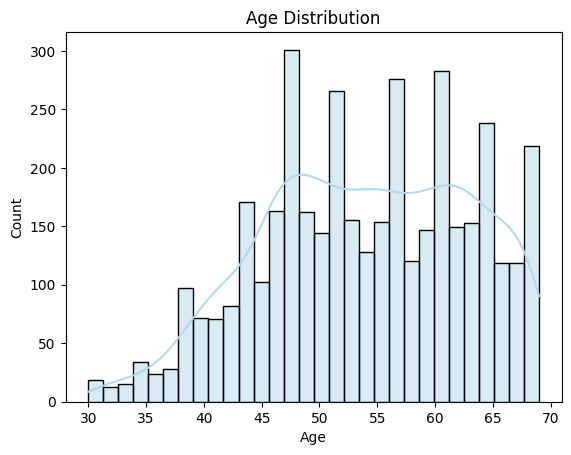

In [ ]:
# Visualize age distribution
sns.histplot(C_df["Age"], bins=30, kde=True, color="#B5D8EB")
plt.title("Age Distribution")
plt.show()

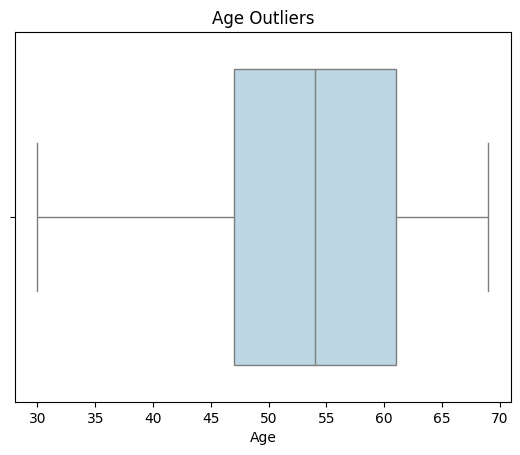

In [ ]:
# Detect outliers in age
sns.boxplot(x=C_df["Age"], color="#B5D8EB")
plt.title("Age Outliers")
plt.show()

Most patients are between 45 and 65 years old, and the age distribution appears smooth and realistic, which means age is a meaningful feature in this dataset.

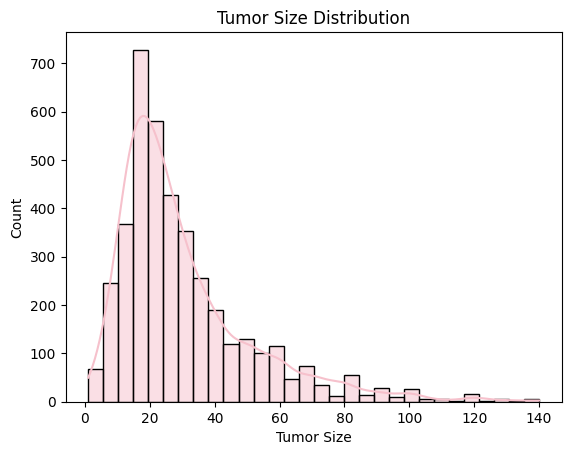

In [ ]:
# Visualize tumor size distribution
sns.histplot(C_df["Tumor Size"], bins=30, kde=True, color="#F6C1CC")
plt.title("Tumor Size Distribution")
plt.show()

Since tumor size is a critical feature for prediction and its distribution is right-skewed,
further analysis is required to better understand its behavior and impact on the model.

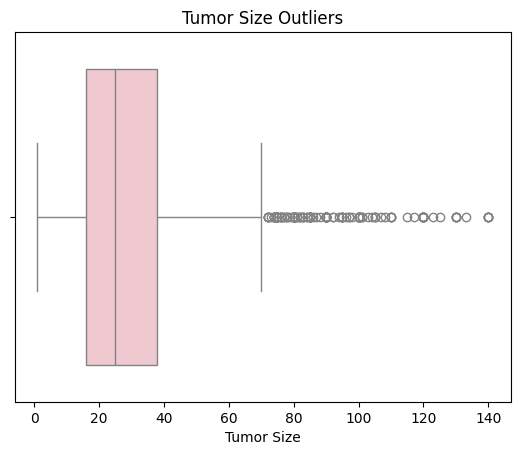

In [118]:
# Detect outliers using boxplot
sns.boxplot(x=C_df["Tumor Size"], color="#F6C1CC")
plt.title("Tumor Size Outliers")
plt.show()

The boxplot confirms that tumor size values are concentrated in lower ranges,
with fewer cases showing very large tumor sizes, reflecting a skewed distribution
and varying disease severity.

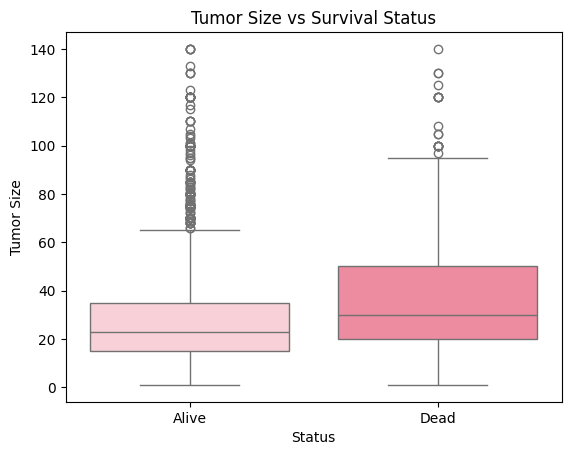

In [ ]:
# Compare tumor size with survival status
sns.boxplot(x="Status", y="Tumor Size", hue="Status", data=C_df, palette=["#FFCAD4", "#FD7C96"], legend=False)
plt.title("Tumor Size vs Survival Status")
plt.show()

This plot shows that patients with larger tumor sizes are more likely to belong to the dead group, which confirms that tumor size is a strong predictive feature.

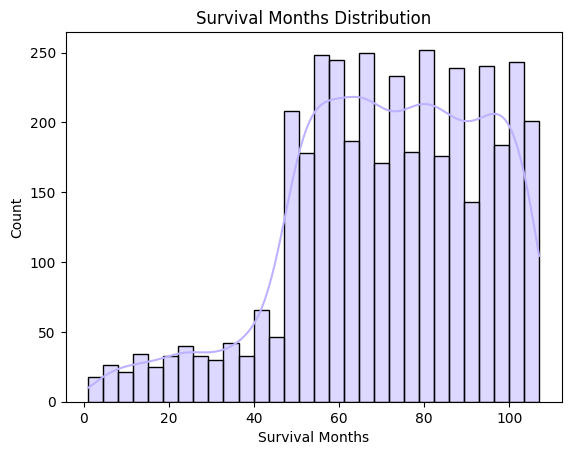

In [78]:
# Visualize survival months distribution
sns.histplot(C_df["Survival Months"], bins=30, kde=True, color="#BDB2FF")
plt.title("Survival Months Distribution")
plt.show()

The distribution of survival months shows variability in patient outcomes,
with most patients having moderate to long survival durations.
This highlights differences in disease severity and treatment response.

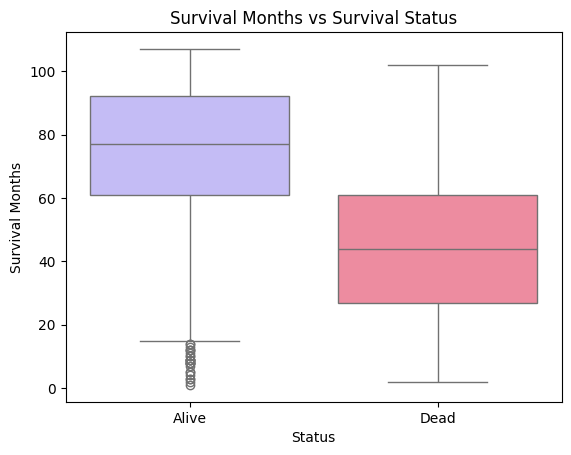

In [83]:
# Compare survival months with survival status
sns.boxplot(x="Status", y="Survival Months", hue="Status", data=C_df, palette=["#BDB2FF", "#FD7C96"], legend=False)
plt.title("Survival Months vs Survival Status")
plt.show()

This plot shows a clear difference in survival duration between alive and dead patients.
Alive patients tend to have longer survival months, indicating a strong relationship
between survival duration and survival status.

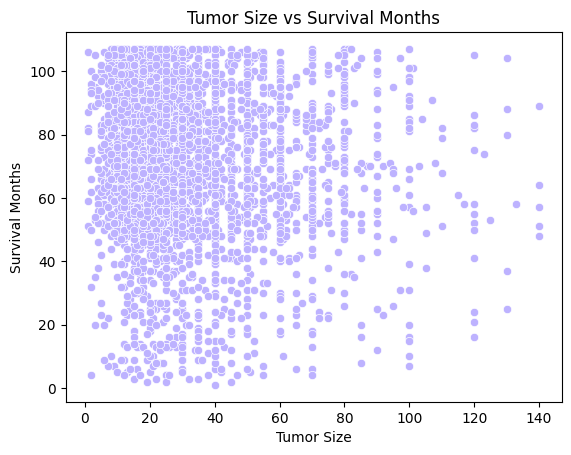

In [ ]:
# Relationship between tumor size and survival duration
sns.scatterplot(x="Tumor Size", y="Survival Months", data=C_df, color="#BDB2FF")
plt.title("Tumor Size vs Survival Months")
plt.show()

The scatter plot does not show a clear linear relationship between tumor size and survival months.
Although tumor size is clinically important, the high variability indicates that survival duration is influenced by multiple factors, not tumor size alone.

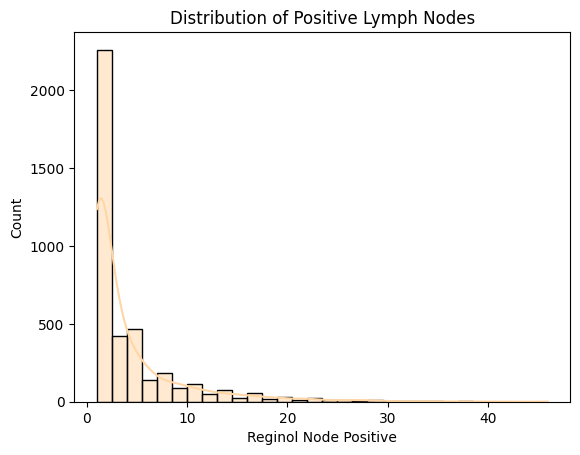

In [68]:
# Visualize distribution of positive lymph nodes
sns.histplot(C_df["Reginol Node Positive"], bins=30, kde=True, color="#FFD6A5")
plt.title("Distribution of Positive Lymph Nodes")
plt.show()

The distribution shows that most patients have a low number of positive lymph nodes,
while higher values are less common.

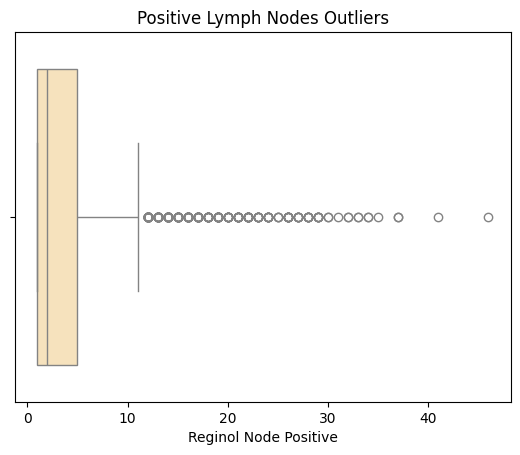

In [69]:
# Detect outliers in positive lymph nodes
sns.boxplot(x=C_df["Reginol Node Positive"], color="#FFE5B4")
plt.title("Positive Lymph Nodes Outliers")
plt.show()

The boxplot is used to highlight extreme values and identify cases with unusually
high numbers of positive lymph nodes.

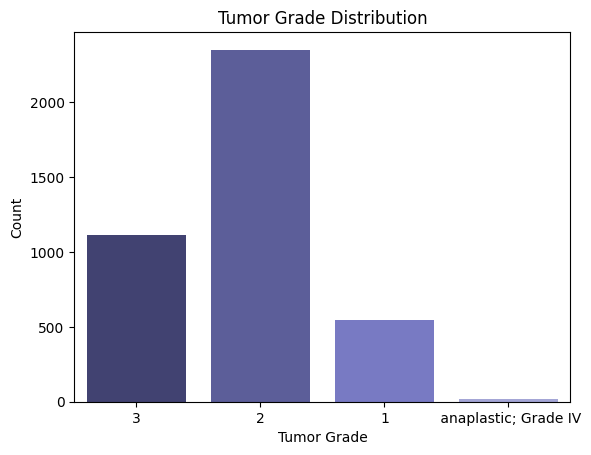

In [ ]:
# Visualize tumor grade distribution
sns.countplot(x="Grade", hue="Grade", data=C_df, palette="tab20b", legend=False)
plt.title("Tumor Grade Distribution")
plt.xlabel("Tumor Grade")
plt.ylabel("Count")
plt.show()

This plot shows the distribution of tumor grades.
Most patients fall into Grade 2, indicating a moderate level of tumor aggressiveness,
while fewer patients are observed in Grade 1 and Grade 3.
Very few cases belong to Grade IV, suggesting it is rare in this dataset.

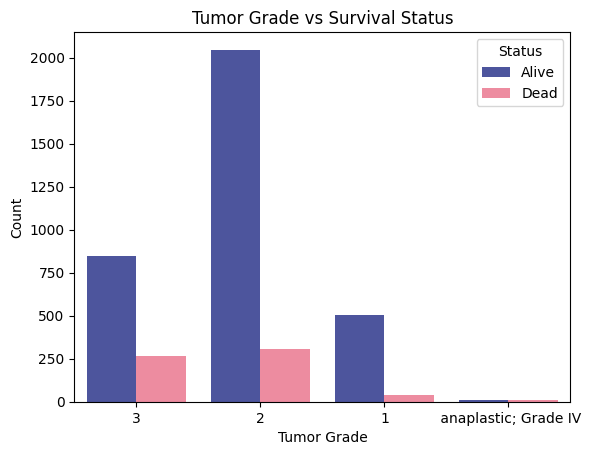

In [91]:
# Compare tumor grade with survival status
sns.countplot(x="Grade", hue="Status", data=C_df, palette=["#404AAA", "#FD7C96"]
)
plt.title("Tumor Grade vs Survival Status")
plt.xlabel("Tumor Grade")
plt.ylabel("Count")
plt.show()

Lower tumor grades are generally associated with better survival outcomes compared to higher grades.

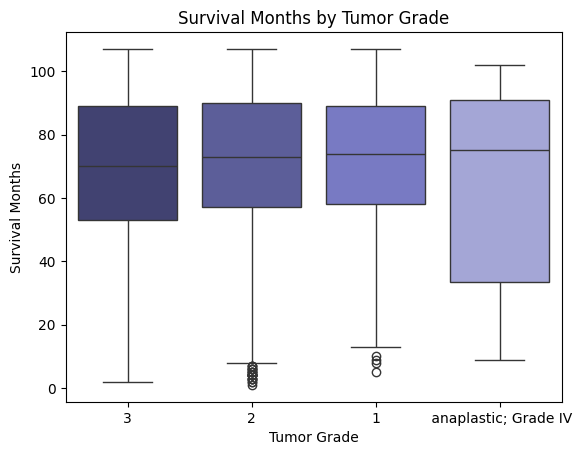

In [89]:
# Compare tumor grade with survival months
sns.boxplot(x="Grade", y="Survival Months", hue="Grade", data=C_df, palette="tab20b", legend=False)
plt.title("Survival Months by Tumor Grade")
plt.xlabel("Tumor Grade")
plt.ylabel("Survival Months")
plt.show()

Survival months vary across tumor grades, with slight differences between lower and higher grades.

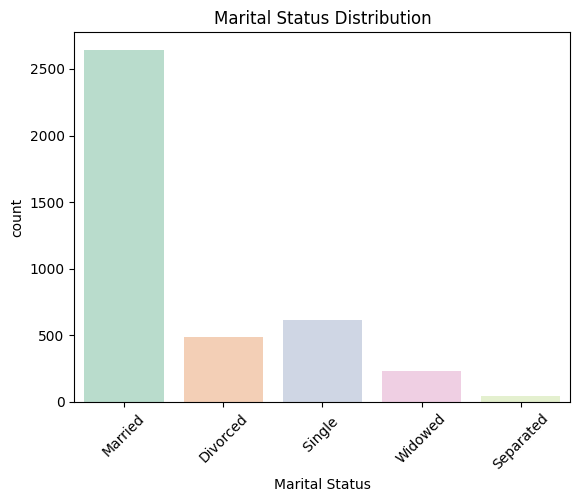

In [73]:
# Visualize marital status distribution
sns.countplot(x="Marital Status", hue="Marital Status", data=C_df, palette="Pastel2", legend=False)
plt.title("Marital Status Distribution")
plt.xticks(rotation=45)
plt.show()

This plot provides an overview of patients’ social status, which may indirectly influence
their psychological well-being and support system, and consequently their survival outcomes.

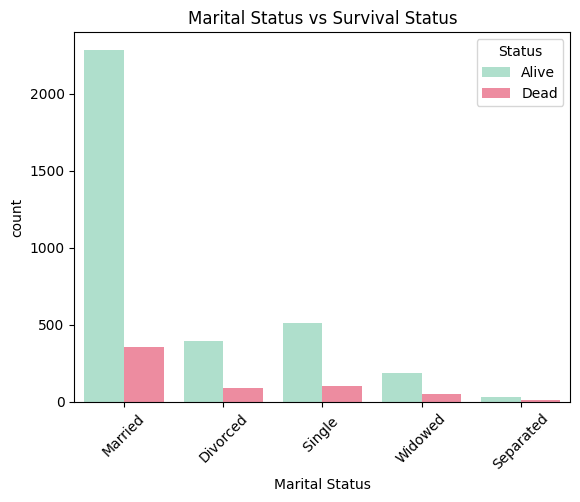

In [75]:
# Compare marital status with survival status
sns.countplot(x="Marital Status", hue="Status", data=C_df, palette=["#A7E7CD", "#FD7C96"])
plt.title("Marital Status vs Survival Status")
plt.xticks(rotation=45)
plt.show()

The plot suggests that survival status varies across marital groups.
Married patients appear more frequently in the alive group, which may reflect
the role of social and psychological support.

In [17]:
# Select only numerical columns
numeric_df = C_df.select_dtypes(include="number")

In [18]:
# Compute correlation matrix
corr = numeric_df.corr()

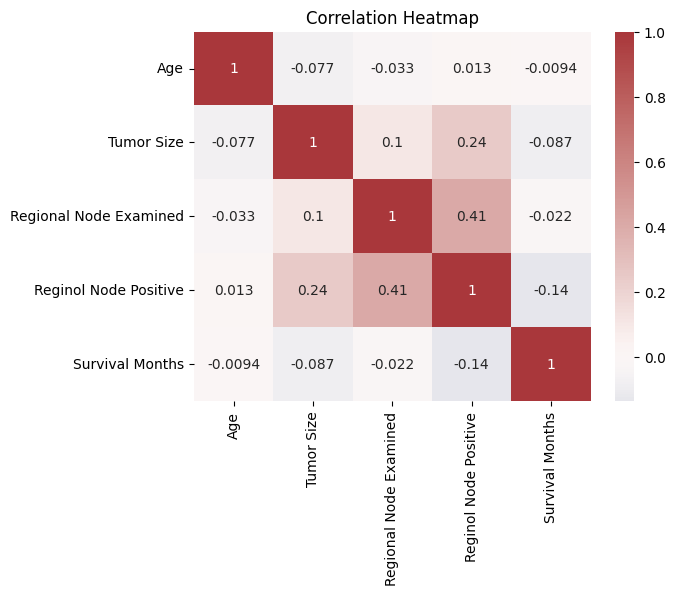

In [104]:
# Visualize correlation heatmap
sns.heatmap(corr, annot=True, cmap="vlag", center=0)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap indicates that most numerical features have weak linear relationships with survival months. This suggests that patient survival is influenced by multiple interacting factors rather than a single variable, highlighting the need for machine learning models to capture these complex patterns.